SECTION 1: DATA INSPECTION

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

--- Statistical Description

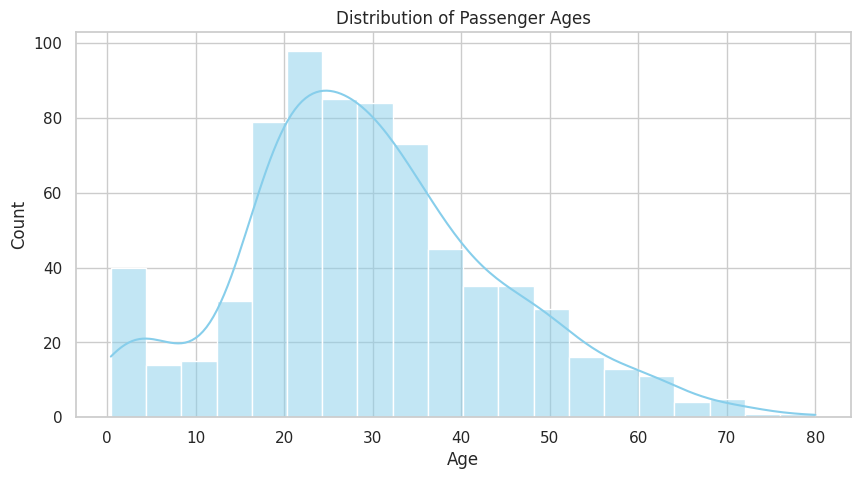

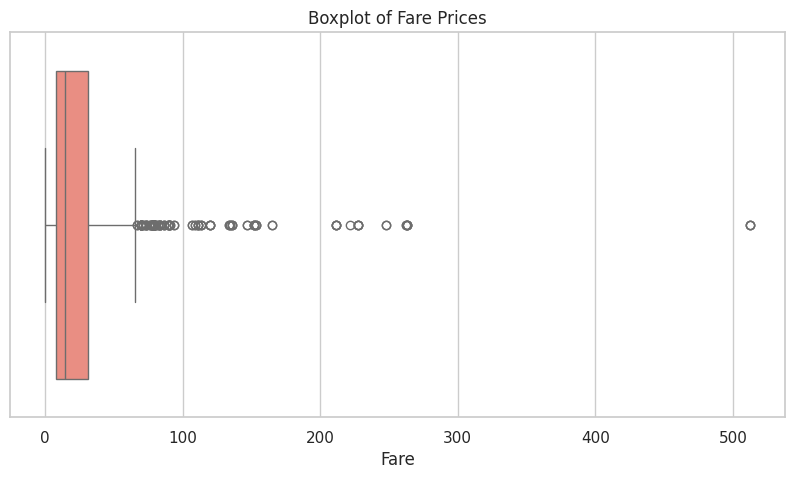


[OBSERVATION 2]: Age distribution is slightly right-skewed (most passengers 20-40 yrs).
[OBSERVATION 2]: Fare boxplot shows significant outliers (some paid much higher fares).

SECTION 3: BIVARIATE & MULTIVARIATE ANALYSIS


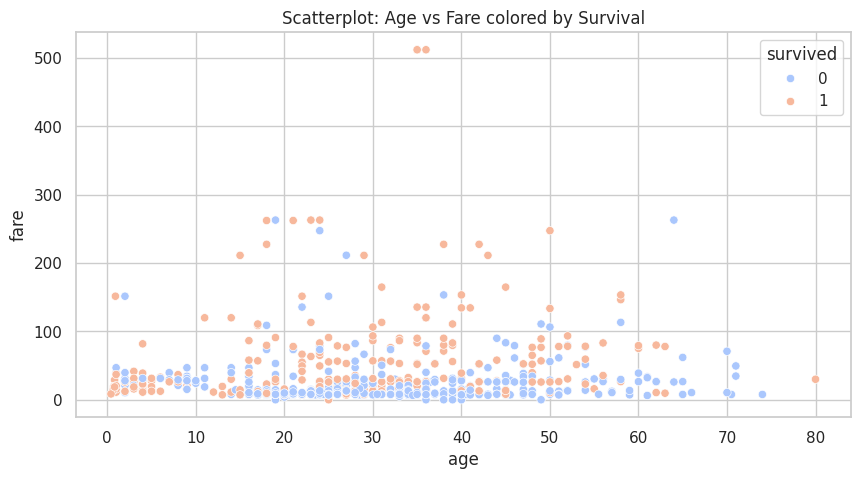

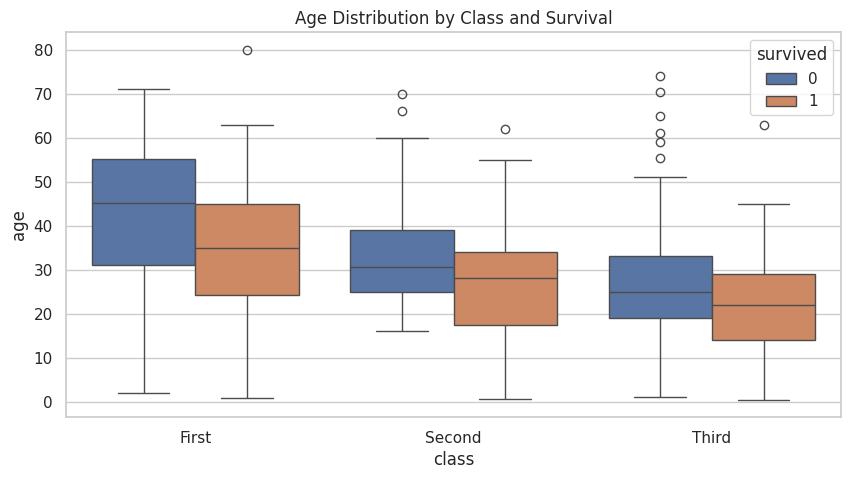


[OBSERVATION 3]: Higher fares sometimes correlate with survival (visible in scatterplot).
[OBSERVATION 3]: First-class passengers tend to be older; class impacts survival chances.


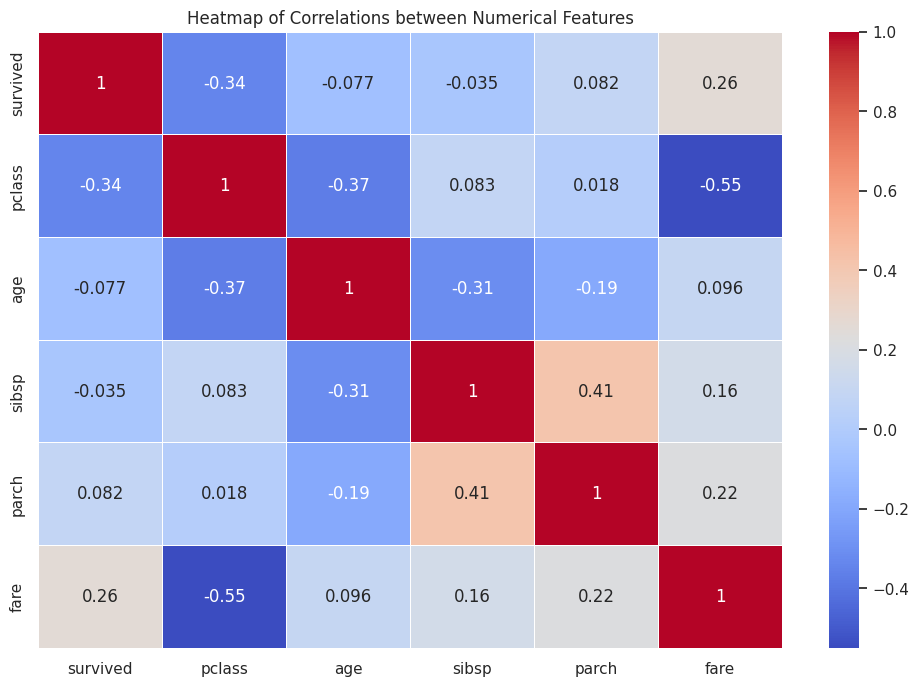

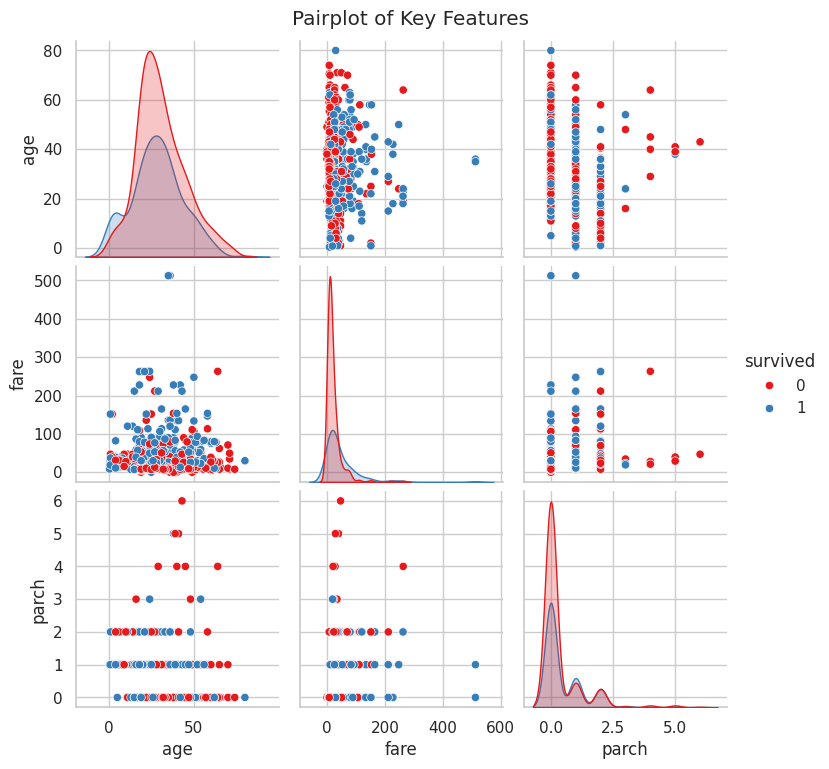


[OBSERVATION 4]: Heatmap shows 'fare' has a positive correlation with 'survived'.
[OBSERVATION 4]: Pairplot confirms separation in 'fare' between survived/not survived groups.

SECTION 4: FINAL SUMMARY OF FINDINGS

1. Survival Rate: Approximately 38% of passengers survived.
2. Class Impact: Passenger class is a strong indicator; 1st Class had better survival chances.
3. Fare Correlation: Positive correlation between fare price and survival (wealth played a role).
4. Age Factor: Children (lower age) had a slightly higher survival rate.
5. Data Quality: Missing values in 'Age' and 'Deck' should be handled before modeling.



In [4]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. LOAD DATA
# Using seaborn built-in dataset for immediate access
df = sns.load_dataset('titanic')


# 3. DATA INSPECTION & STATISTICAL SUMMARY
# (Guideline: Use .info(), .describe(), .value_counts())
print("="*50)
print("SECTION 1: DATA INSPECTION")
print("="*50)

# Check data types and non-null counts
print("\n--- Data Info ---")
print(df.info())

# Statistical summary of numerical columns
print("\n--- Statistical Description ---")
print(df.describe())

# Check unique values for categorical columns
print("\n--- Value Counts for 'Survived' ---")
print(df['survived'].value_counts())

print("\n--- Value Counts for 'Class' ---")
print(df['class'].value_counts())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# OBSERVATION 1
print("\n[OBSERVATION 1]: The dataset contains passenger info. There are missing values in 'age', 'deck', and 'embarked'.)")
print("[OBSERVATION 1]: 'survived' is our target variable (0=No, 1=Yes).")


# 4. UNIVARIATE ANALYSIS
# (Guideline: Plot histograms, boxplots)

print("\n" + "="*50)
print("SECTION 2: UNIVARIATE ANALYSIS")
print("="*50)

# Histogram for Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['age'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Boxplot for Fare Distribution
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fare'], color='salmon')
plt.title('Boxplot of Fare Prices')
plt.xlabel('Fare')
plt.show()

# OBSERVATION 2
print("\n[OBSERVATION 2]: Age distribution is slightly right-skewed (most passengers 20-40 yrs).")
print("[OBSERVATION 2]: Fare boxplot shows significant outliers (some paid much higher fares).")


# 5. BIVARIATE & MULTIVARIATE ANALYSIS
# (Guideline: Identify relationships, Scatterplots, Heatmap, Pairplot)

print("\n" + "="*50)
print("SECTION 3: BIVARIATE & MULTIVARIATE ANALYSIS")
print("="*50)

# Scatterplot: Age vs Fare
plt.figure(figsize=(10, 5))
sns.scatterplot(x='age', y='fare', data=df, hue='survived', palette='coolwarm')
plt.title('Scatterplot: Age vs Fare colored by Survival')
plt.show()

# Boxplot: Survival vs Class
plt.figure(figsize=(10, 5))
sns.boxplot(x='class', y='age', hue='survived', data=df)
plt.title('Age Distribution by Class and Survival')
plt.show()

# OBSERVATION 3
print("\n[OBSERVATION 3]: Higher fares sometimes correlate with survival (visible in scatterplot).")
print("[OBSERVATION 3]: First-class passengers tend to be older; class impacts survival chances.")


# 6. CORRELATION & PAIRPLOT
# (Guideline: Use sns.pairplot(), sns.heatmap())

# Heatmap: Correlation Matrix
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Heatmap of Correlations between Numerical Features')
plt.show()

# Pairplot: Relationships between multiple variables
sns.pairplot(df[['survived', 'age', 'fare', 'parch']], hue='survived', palette='Set1')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

# OBSERVATION 4
print("\n[OBSERVATION 4]: Heatmap shows 'fare' has a positive correlation with 'survived'.")
print("[OBSERVATION 4]: Pairplot confirms separation in 'fare' between survived/not survived groups.")


# 7. SUMMARY OF FINDINGS
# (Guideline: Provide summary of findings)

print("\n" + "="*50)
print("SECTION 4: FINAL SUMMARY OF FINDINGS")
print("="*50)

summary = """
1. Survival Rate: Approximately 38% of passengers survived.
2. Class Impact: Passenger class is a strong indicator; 1st Class had better survival chances.
3. Fare Correlation: Positive correlation between fare price and survival (wealth played a role).
4. Age Factor: Children (lower age) had a slightly higher survival rate.
5. Data Quality: Missing values in 'Age' and 'Deck' should be handled before modeling.
"""
print(summary)